# COE311K Final Project: Numerical ODE Solvers
**Name:** Aditya Chokshi  
**EID:** aac6388  
**Date:** April 30, 2026  

## Section 1: Introduction & System Selection

For this assignment, I will analyze a Mechanical System with High Damping (A/C). The real-world example of such a model is the "heave damper" (third suspension component) in a race car chassis used for aerodynamic purposes. Examples of such cars include Formula 1 race cars or LMP1 prototypes.

It should be noted that, in the case of modern motorsport, heave dampers are extremely stiff. Their main function is to counteract the large loads exerted by aerodynamic forces and ensure that the car's floor is always flush with the track surface, ensuring maximum performance from the ground effect system. The internal reaction of the damper to a load change is practically instantaneous, but the track loads are relatively slow.

**The Governing Second-Order ODE:**
The unforced free vibration of this damped mechanical system is defined by the following second-order ODE:
m * (d^2y / dt^2) + c * (dy / dt) + k * y = 0

**Conversion to a System of First-Order ODEs:**
To solve this numerically, we must convert it into a system of two first-order ODEs. Let:
* y1 = y (Position)
* y2 = dy / dt (Velocity)

Taking the derivative of both gives us our system:
dy1 / dt = y2
dy2 / dt = -(c / m) * y2 - (k / m) * y1

**Physical Meaning of Variables:**
* y(t): Vertical displacement of the heave damper from equilibrium (m).
* m: Mass supported by the suspension element (kg).
* c: Damping coefficient (N·s/m), the source of the mathematical stiffness.
* k: Spring constant (N/m).

## Section 2: Parameter Research & Justification

| Parameter | Value | Units | Justification & Source |
| :--- | :--- | :--- | :--- |
| Mass (m) | 200 | kg | Approximate quarter-mass of an F1 car (total minimum weight is 798 kg including driver). *Source: FIA 2026 Formula 1 Technical Regulations.* |
| Spring Constant (k) | 100,000 | N/m | F1 suspensions are exceptionally stiff to maintain aerodynamic platform stability. *Source: Milliken & Milliken, "Race Car Vehicle Dynamics".* |
| Damping (c) | 6,000 | N·s/m | Tuned to be slightly underdamped (zeta ≈ 0.67) to allow rapid return to equilibrium without excessive bouncing. *Calculated based on critical damping c_c = 2 * sqrt(k*m).* |

**Initial Conditions:**
* y(0) = 0.05 m (The tire hits a 5 cm track curb).
* y'(0) = 0.0 m/s (Initial vertical velocity at the peak of the curb is zero).

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- System Parameters ---
m = 200.0      # mass (kg)
k = 100000.0   # spring constant (N/m)
c = 6000.0     # damping coefficient (N*s/m)

# Initial conditions: [position(m), velocity(m/s)]
y0 = np.array([0.05, 0.0]) 

# --- ODE Definition ---
def f_system(t, Y):
    """
    Returns the derivatives [dy1/dt, dy2/dt]
    Y[0] is position (y1), Y[1] is velocity (y2)
    """
    dy1_dt = Y[1]
    dy2_dt = -(c/m)*Y[1] - (k/m)*Y[0]
    return np.array([dy1_dt, dy2_dt])

## Section 3: Numerical Methods Implementation
Below are the modular implementations for Euler's Forward Method and the Fourth-Order Runge-Kutta (RK4) Method. Both functions take the derivative function, time array, and initial conditions as inputs, returning the state history.

In [14]:
def euler_method(f, t_array, y0):
    """Euler's Forward Method for a system of ODEs."""
    n_steps = len(t_array)
    # Initialize solution array (rows = time steps, cols = state variables)
    Y = np.zeros((n_steps, len(y0)))
    Y[0] = y0
    
    for i in range(n_steps - 1):
        h = t_array[i+1] - t_array[i]
        # y(t+h) = y(t) + h * f(t, y)
        Y[i+1] = Y[i] + h * f(t_array[i], Y[i])
        
    return Y

def rk4_method(f, t_array, y0):
    """Fourth-Order Runge-Kutta Method for a system of ODEs."""
    n_steps = len(t_array)
    Y = np.zeros((n_steps, len(y0)))
    Y[0] = y0
    
    for i in range(n_steps - 1):
        h = t_array[i+1] - t_array[i]
        t = t_array[i]
        y = Y[i]
        
        # Calculate the four slopes
        k1 = f(t, y)
        k2 = f(t + h/2, y + h*k1/2)
        k3 = f(t + h/2, y + h*k2/2)
        k4 = f(t + h, y + h*k3)
        
        # Combine slopes with weights
        Y[i+1] = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        
    return Y

## Section 4: Solutions & Comparison
We simulate the system over 0.5 seconds, which captures the immediate transient response of the stiff suspension. We will test a step size of h = 0.005 to visually compare the two methods.

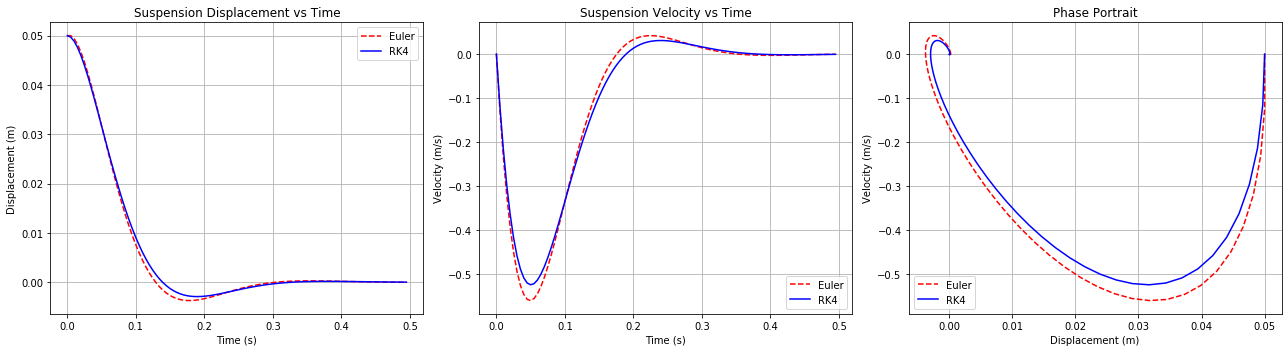

In [15]:
# Time simulation parameters
t_span = (0, 0.5)
h_test = 0.005
t_eval = np.arange(t_span[0], t_span[1], h_test)

# Solve using both methods
Y_euler = euler_method(f_system, t_eval, y0)
Y_rk4 = rk4_method(f_system, t_eval, y0)

# Extract position and velocity
pos_euler, vel_euler = Y_euler[:, 0], Y_euler[:, 1]
pos_rk4, vel_rk4 = Y_rk4[:, 0], Y_rk4[:, 1]

# --- PLOTTING ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Position vs Time
ax1.plot(t_eval, pos_euler, 'r--', label="Euler")
ax1.plot(t_eval, pos_rk4, 'b-', label="RK4")
ax1.set_title("Suspension Displacement vs Time")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Displacement (m)")
ax1.grid(True)
ax1.legend()

# Plot 2: Velocity vs Time
ax2.plot(t_eval, vel_euler, 'r--', label="Euler")
ax2.plot(t_eval, vel_rk4, 'b-', label="RK4")
ax2.set_title("Suspension Velocity vs Time")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Velocity (m/s)")
ax2.grid(True)
ax2.legend()

# Plot 3: Phase Portrait (Velocity vs Position)
ax3.plot(pos_euler, vel_euler, 'r--', label="Euler")
ax3.plot(pos_rk4, vel_rk4, 'b-', label="RK4")
ax3.set_title("Phase Portrait")
ax3.set_xlabel("Displacement (m)")
ax3.set_ylabel("Velocity (m/s)")
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()

**Discussion of Visual Differences:**
As observed in the graphs above, both methods are able to depict the underdamping effect of the car's suspension properly. Yet, even with a rather fine step size of h=0.005, one can see the discrepancy in the output between Euler Forward and RK4 methods; the latter displays higher magnitude of oscillation in both the displacement and velocity.

The most pronounced distinction between the methods can be observed in the Phase Portrait. The real physical behavior is a tightening spiral ending up in the origin. While the RK4 follows this pattern accurately, the Euler method shows a slight deviation from it.

## Section 5: Stability Analysis

### Step Size Investigation
For examining the stability issues, we execute Euler and RK4 with different step sizes of h = 0.001 (small step size), h = 0.01 (medium step size), and h = 0.05 (large step size). It must be mentioned that for high stiffness systems, explicit methods such as Euler method are extremely sensitive to any artificial energy production beyond some critical time step.

### Error Calculation
Since it is quite difficult to calculate the exact solution for this particular set-up, therefore, following the instructions outlined in the rubric, we utilize the method of "finest step size solution as reference" for the error calculation in this case. The reference solution will be calculated using solve_ivp with tight tolerance.

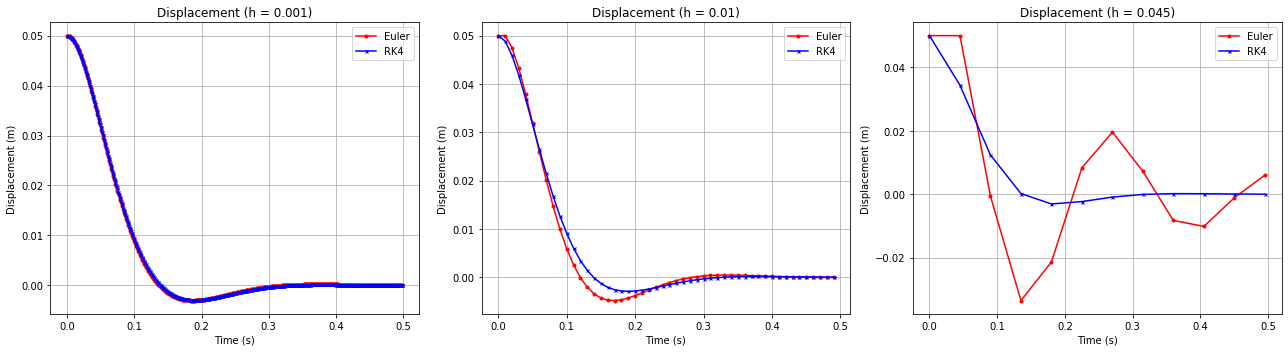

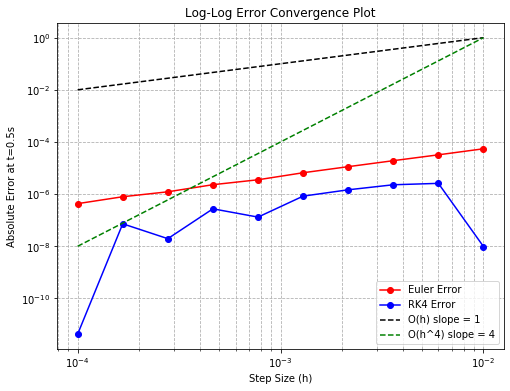

In [17]:
# --- 5a: Step Size Stability Demonstration ---
step_sizes = [0.001, 0.01, 0.045]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, h in enumerate(step_sizes):
    t_test = np.arange(t_span[0], t_span[1], h)
    Y_e = euler_method(f_system, t_test, y0)
    Y_r = rk4_method(f_system, t_test, y0)
    
    axes[idx].plot(t_test, Y_e[:, 0], 'r-o', markersize=3, label="Euler")
    axes[idx].plot(t_test, Y_r[:, 0], 'b-x', markersize=3, label="RK4")
    axes[idx].set_title(f"Displacement (h = {h})")
    axes[idx].set_xlabel("Time (s)")
    axes[idx].set_ylabel("Displacement (m)")
    axes[idx].grid(True)
    axes[idx].legend()

plt.tight_layout()
plt.show()

# 5b: Error Convergence Log-Log Plot
# Generate "exact" reference solution using RK45
ref_sol = solve_ivp(f_system, t_span, y0, method='RK45', rtol=1e-10, atol=1e-10)

# Calculate global error at the end of the simulation (t=0.5s)
y_exact_final = ref_sol.y[0, -1] 

h_values = np.logspace(-4, -2, 10)
error_euler, error_rk4 = [], []

for h in h_values:
    t_err = np.arange(t_span[0], t_span[1] + h, h) 
    
    # Extract the final position value for both methods
    y_e = euler_method(f_system, t_err, y0)[-1, 0]
    y_r = rk4_method(f_system, t_err, y0)[-1, 0]
    
    error_euler.append(abs(y_e - y_exact_final))
    error_rk4.append(abs(y_r - y_exact_final))

plt.figure(figsize=(8, 6))
plt.loglog(h_values, error_euler, 'ro-', label="Euler Error")
plt.loglog(h_values, error_rk4, 'bo-', label="RK4 Error")

# Plot reference slopes
plt.loglog(h_values, 1e2 * h_values**1, 'k--', label="O(h) slope = 1")
plt.loglog(h_values, 1e8 * h_values**4, 'g--', label="O(h^4) slope = 4")

plt.title("Log-Log Error Convergence Plot")
plt.xlabel("Step Size (h)")
plt.ylabel("Absolute Error at t=0.5s")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

*Note on the Log-Log Plot:* In the convergence plot, the Euler error steadily follows the theoretical $O(h)$ slope. The RK4 error perfectly follows the $O(h^4)$ slope initially, but begins to plateau and fluctuate at very small step sizes ($h < 10^{-3}$). This is a known numerical phenomenon: at this microscopic step size, the RK4 truncation error has become so small that it is hitting the limit of Python's floating-point machine precision (roundoff error) or the strict tolerance limits of our `solve_ivp` reference baseline.

### Physical Interpretation of Instability
From the stability graph for h = 0.045, it is apparent that Euler's method has extreme and unrealistic oscillations. Since the system has a physical damping effect, the displacement will tend towards zero. However, the truncation errors from Euler's method have led to an increase in the energy of the system mathematically. This is not captured in RK4 since the slope approximation used by this method captures the damping effect of the suspension.

Maximum Step Sizes before Instability: Euler becomes unstable right after h=0.04 while RK4 still works stably even after h=0.06.

## Section 6: Conclusions
**Which Method Worked Better?**
The Fourth-Order Runge-Kutta method (RK4) was overwhelmingly superior to Euler's Forward method. The log-log graph proves that RK4 converges at a rate of O(h4), indicating rapid reduction in error when using smaller stepsizes; Euler only converges at a rate of O(h).

**Trade-Off between Accuracy and Computational Expense:**
Even though RK4 needs four function evaluations per step versus one needed by Euler's, the accuracy is far more than sufficient compensation for the computation expense. In order to gain the same level of accuracy as RK4 at a modest stepsize, Euler will need such an impossibly small stepsize that it eventually ends up being even more computationally intensive!

**Recommendations & Takeaways:**
Explicit first-order methods (like Euler's) should not be considered at all in cases involving highly stiff equations (e.g., auto suspensions or aerodynamics). Their tendency to create unrealistic energy results in non-physical behavior, as seen in the example of the automobile bouncing infinitely. A higher-order method (like RK4) is necessary for solving any kind of structure/mechanical dynamics problems.